In [1]:
import os
import re

def extract_asr_acc_from_log(log_file):
    """从日志文件中提取第100轮的asr和acc"""
    asr = None
    acc = None
    with open(log_file, 'r') as file:
        for line in file:
            # 查找是否为第100轮的相关信息
            if 'Round number: 100' in line:
                # 寻找asr和acc
                for next_line in file:
                    if 'Attack Success Rate' in next_line:
                        asr = float(next_line.split(':')[-1].strip())
                    if 'Test Accurancy' in next_line:
                        acc = float(next_line.split(':')[-1].strip())
                    # 如果找到了asr和acc，就结束读取
                    if asr is not None and acc is not None:
                        return asr, acc
    return asr, acc

def process_logs_in_folder(folder_path):
    """遍历文件夹中的所有日志文件并提取信息"""
    results = {}
    for filename in os.listdir(folder_path):
        if filename.endswith('.log'):
            log_file_path = os.path.join(folder_path, filename)
            asr, acc = extract_asr_acc_from_log(log_file_path)
            if asr is not None and acc is not None:
                results[filename] = {'asr': asr, 'acc': acc}
    return results

# 使用示例
folder_path = './'  # 请将此路径替换为您的日志文件夹路径
results = process_logs_in_folder(folder_path)

# 打印结果
for log_file, data in results.items():
    print(f"Log file: {log_file}, ASR: {data['asr']}, ACC: {data['acc']}")


Log file: 0.0002.log, ASR: 0.274, ACC: 0.583
Log file: 0.0004.log, ASR: 0.2747, ACC: 0.5828
Log file: 0.0006.log, ASR: 0.2767, ACC: 0.5827
Log file: 0.0008.log, ASR: 0.272, ACC: 0.582
Log file: 0.001.log, ASR: 0.2687, ACC: 0.5824
Log file: 0.0012.log, ASR: 0.276, ACC: 0.582
Log file: 0.0014.log, ASR: 0.274, ACC: 0.5814
Log file: 0.0016.log, ASR: 0.27, ACC: 0.5819
Log file: 0.0018.log, ASR: 0.2733, ACC: 0.5814
Log file: 0.002.log, ASR: 0.2753, ACC: 0.5813
Log file: 0.0022.log, ASR: 0.2773, ACC: 0.5807
Log file: 0.0024.log, ASR: 0.2767, ACC: 0.5813
Log file: 0.0026.log, ASR: 0.2753, ACC: 0.5815
Log file: 0.0028.log, ASR: 0.274, ACC: 0.5808
Log file: 0.003.log, ASR: 0.2747, ACC: 0.5804
Log file: 0.0032.log, ASR: 0.2773, ACC: 0.5808
Log file: 0.0034.log, ASR: 0.274, ACC: 0.5812
Log file: 0.0036.log, ASR: 0.272, ACC: 0.5815
Log file: 0.0038.log, ASR: 0.274, ACC: 0.5819
Log file: 0.004.log, ASR: 0.2747, ACC: 0.5806
Log file: 0.0042.log, ASR: 0.272, ACC: 0.5814
Log file: 0.0044.log, ASR: 0.27

In [5]:
import os
import re

def extract_asr_acc_from_log(log_file):
    """从日志文件中提取第100轮的asr和acc"""
    asr = None
    acc = None
    with open(log_file, 'r') as file:
        for line in file:
            # 查找是否为第100轮的相关信息
            if 'Round number: 100' in line:
                # 寻找asr和acc
                for next_line in file:
                    if 'Attack Success Rate' in next_line:
                        asr = float(next_line.split(':')[-1].strip())
                    if 'Test Accurancy' in next_line:
                        acc = float(next_line.split(':')[-1].strip())
                    # 如果找到了asr和acc，就结束读取
                    if asr is not None and acc is not None:
                        return asr, acc
    return asr, acc

def process_logs_in_folder(folder_path):
    """遍历文件夹中的所有日志文件并提取信息"""
    asr_list = []
    acc_list = []
    file_numbers = []  # 存储文件名中的数字部分，用于排序
    
    for filename in os.listdir(folder_path):
        if filename.endswith('.log'):
            log_file_path = os.path.join(folder_path, filename)
            asr, acc = extract_asr_acc_from_log(log_file_path)
            if asr is not None and acc is not None:
                # 提取文件名中的数字部分（支持小数）
                file_number = float(re.search(r'\d+(\.\d+)?', filename).group())
                asr_list.append(asr)
                acc_list.append(acc)
                file_numbers.append(file_number)

    # 根据文件名中的数字部分对asr和acc进行排序
    sorted_indices = sorted(range(len(file_numbers)), key=lambda k: file_numbers[k])
    sorted_asr = [asr_list[i] for i in sorted_indices]
    sorted_acc = [acc_list[i] for i in sorted_indices]
    
    return sorted_asr, sorted_acc, file_numbers

# 使用示例
folder_path = './'  # 请将此路径替换为您的日志文件夹路径
sorted_asr, sorted_acc, file_numbers = process_logs_in_folder(folder_path)

# 打印结果
for i, file_num in enumerate(file_numbers):
    print(f"File Number: {file_num}, ASR: {sorted_asr[i]}, ACC: {sorted_acc[i]}")


File Number: 0.0002, ASR: 0.274, ACC: 0.583
File Number: 0.0004, ASR: 0.2747, ACC: 0.5828
File Number: 0.0006, ASR: 0.2767, ACC: 0.5827
File Number: 0.0008, ASR: 0.272, ACC: 0.582
File Number: 0.001, ASR: 0.2687, ACC: 0.5824
File Number: 0.0012, ASR: 0.276, ACC: 0.582
File Number: 0.0014, ASR: 0.274, ACC: 0.5814
File Number: 0.0016, ASR: 0.27, ACC: 0.5819
File Number: 0.0018, ASR: 0.2733, ACC: 0.5814
File Number: 0.002, ASR: 0.2753, ACC: 0.5813
File Number: 0.0022, ASR: 0.2773, ACC: 0.5807
File Number: 0.0024, ASR: 0.2767, ACC: 0.5813
File Number: 0.0026, ASR: 0.2753, ACC: 0.5815
File Number: 0.0028, ASR: 0.274, ACC: 0.5808
File Number: 0.003, ASR: 0.2747, ACC: 0.5804
File Number: 0.0032, ASR: 0.2773, ACC: 0.5808
File Number: 0.0034, ASR: 0.274, ACC: 0.5812
File Number: 0.0036, ASR: 0.272, ACC: 0.5815
File Number: 0.0038, ASR: 0.274, ACC: 0.5819
File Number: 0.004, ASR: 0.2747, ACC: 0.5806
File Number: 0.0042, ASR: 0.272, ACC: 0.5814
File Number: 0.0044, ASR: 0.276, ACC: 0.5805
File Nu

In [11]:
file_numbers, sorted_asr, sorted_acc = file_numbers[:20:1], sorted_asr[:20:1], sorted_acc[:20:1]

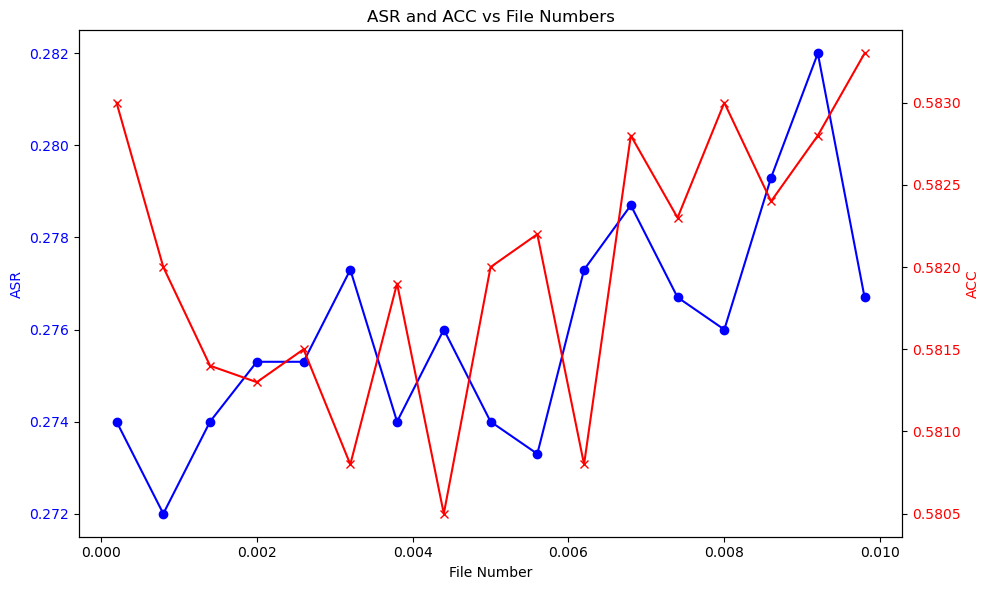

In [9]:
import matplotlib.pyplot as plt

def plot_asr_acc(file_numbers, sorted_asr, sorted_acc):
    """绘制asr和acc随文件数字变化的曲线图（双纵坐标）"""
    # 创建图形
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # 绘制ASR曲线（左边纵坐标）
    ax1.set_xlabel('File Number')
    ax1.set_ylabel('ASR', color='b')
    ax1.plot(file_numbers, sorted_asr, label="ASR", marker='o', color='b')
    ax1.tick_params(axis='y', labelcolor='b')

    # 创建右边的纵坐标轴
    ax2 = ax1.twinx()
    ax2.set_ylabel('ACC', color='r')
    ax2.plot(file_numbers, sorted_acc, label="ACC", marker='x', color='r')
    ax2.tick_params(axis='y', labelcolor='r')

    # 添加标题和标签
    plt.title('ASR and ACC vs File Numbers')

    # 显示图形
    fig.tight_layout()
    plt.show()



# 绘制ASR和ACC的曲线图
plot_asr_acc(file_numbers, sorted_asr, sorted_acc)
